# 不同标的海龟回测：NAV vs Close

本 Notebook 直接调用 `Py_version/turtle_backtest.py` 中现有的数据读取和海龟回测逻辑。

- 每个标的单独绘制：左轴为海龟策略实际 NAV，右轴为标的实际收盘价
- 九个标的对比图使用实际 NAV 金额，并以千分位格式显示纵轴
- 最后给出全部标的的策略净值对比和关键指标表

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter
import pandas as pd

# 兼容从项目根目录或 Py_version 目录启动 Notebook。
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "Py_version").is_dir() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Py_version.turtle_backtest import Parameters, load_raw_data_xlsx, run_backtest

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang HK", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

DATA_FILE = PROJECT_ROOT / "Excel_version" / "海龟法则_stock_data_2026.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "Py_version" / "charts"
DATA_FILE

PosixPath('/Users/antoniozhou/Desktop/Turtle_Trading/Excel_version/海龟法则_stock_data_2026.xlsx')

## 1. 选择标的和回测参数

默认选择原始数据中的全部9个标的（5个指数和4只美股）；修改 `SELECTED_SYMBOLS` 即可增减。

In [2]:
SELECTED_SYMBOLS = [
    "000300.SH",   # 沪深300
    "000905.SH",   # 中证500
    "000852.SH",   # 中证1000
    "932000.CSI",  # 中证2000
    "8841431.WI",  # 万得微盘股指数
    "MSFT.O",      # 微软
    "NVDA.O",      # 英伟达
    "GOOGL.O",     # 谷歌-A
    "AAPL.O",      # 苹果
]

PARAMETERS = Parameters(
    atr_period=20,
    entry_period=20,
    exit_period=10,
    risk_fraction=0.02,
    buy_cost_rate=0.0002,
    sell_cost_rate=0.0007,
    initial_cash=1_000_000,
)

# True 时把图保存到 Py_version/charts；False 时只在 Notebook 中显示。
SAVE_CHARTS = True

## 2. 读取 Raw_data 多标的价格

`load_raw_data_xlsx()` 会识别工作表中每组 `Date/open/high/low/close` 五列数据，并从每个标的第一条完整 OHLC 开始读取。

In [3]:
instruments = load_raw_data_xlsx(DATA_FILE)
instrument_table = pd.DataFrame(
    {
        "代码": [item.symbol for item in instruments],
        "名称": [item.name for item in instruments],
        "行情行数": [len(item.bars) for item in instruments],
    }
)
instrument_table

,代码,名称,行情行数
0,000300.SH,沪深300,5152
1,8841431.WI,万得微盘股指数,5152
2,000905.SH,中证500,5152
3,000852.SH,中证1000,5152
4,932000.CSI,中证2000,3028
5,MSFT.O,微软(MICROSOFT),5152
6,NVDA.O,英伟达(NVIDIA),5152
7,GOOGL.O,谷歌(ALPHABET)-A,5152
8,AAPL.O,苹果(APPLE),5152


## 3. 对所选标的运行海龟回测

这里直接调用项目中的 `run_backtest()`。日期若为 Excel 序列值，会转换为绘图所需的日期。

In [4]:
def to_datetime(values):
    series = pd.Series(values)
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_datetime(series, unit="D", origin="1899-12-30")
    return pd.to_datetime(series)


instrument_by_symbol = {item.symbol: item for item in instruments}
missing = [symbol for symbol in SELECTED_SYMBOLS if symbol not in instrument_by_symbol]
if missing:
    raise ValueError(f"数据文件中找不到这些代码：{missing}")

results = {}
summary_records = []

for symbol in SELECTED_SYMBOLS:
    instrument = instrument_by_symbol[symbol]
    rows, summary = run_backtest(instrument.bars, PARAMETERS)
    frame = pd.DataFrame(
        {
            "Date": to_datetime([row.date for row in rows]),
            "NAV": [row.nav for row in rows],
            "Close": [row.clean_close for row in rows],
            "NAV Index": [row.nav_index for row in rows],
            "Close Index": [row.close_index for row in rows],
            "Drawdown": [row.drawdown for row in rows],
            "Trade": [row.trade for row in rows],
        }
    ).set_index("Date")
    results[symbol] = {"instrument": instrument, "frame": frame, "summary": summary}
    summary_records.append(
        {
            "代码": symbol,
            "名称": instrument.name,
            "期末净值": summary.ending_nav,
            "总收益率": summary.total_return,
            "年化收益率": summary.annualized_return,
            "最大回撤": summary.max_drawdown,
            "年化波动率": summary.annualized_volatility,
            "夏普比率": summary.sharpe_ratio,
            "买入次数": summary.buys,
            "持仓时间": summary.time_in_market,
        }
    )

print(f"完成 {len(results)} 个标的回测：" + "、".join(item["instrument"].name for item in results.values()))

完成 9 个标的回测：沪深300、中证500、中证1000、中证2000、万得微盘股指数、微软(MICROSOFT)、英伟达(NVIDIA)、谷歌(ALPHABET)-A、苹果(APPLE)


## 4. 每个标的：NAV（左轴）vs Close（右轴）

蓝线为海龟策略实际 NAV，使用左侧金额轴；橙线为标的实际收盘价，使用右侧价格轴。

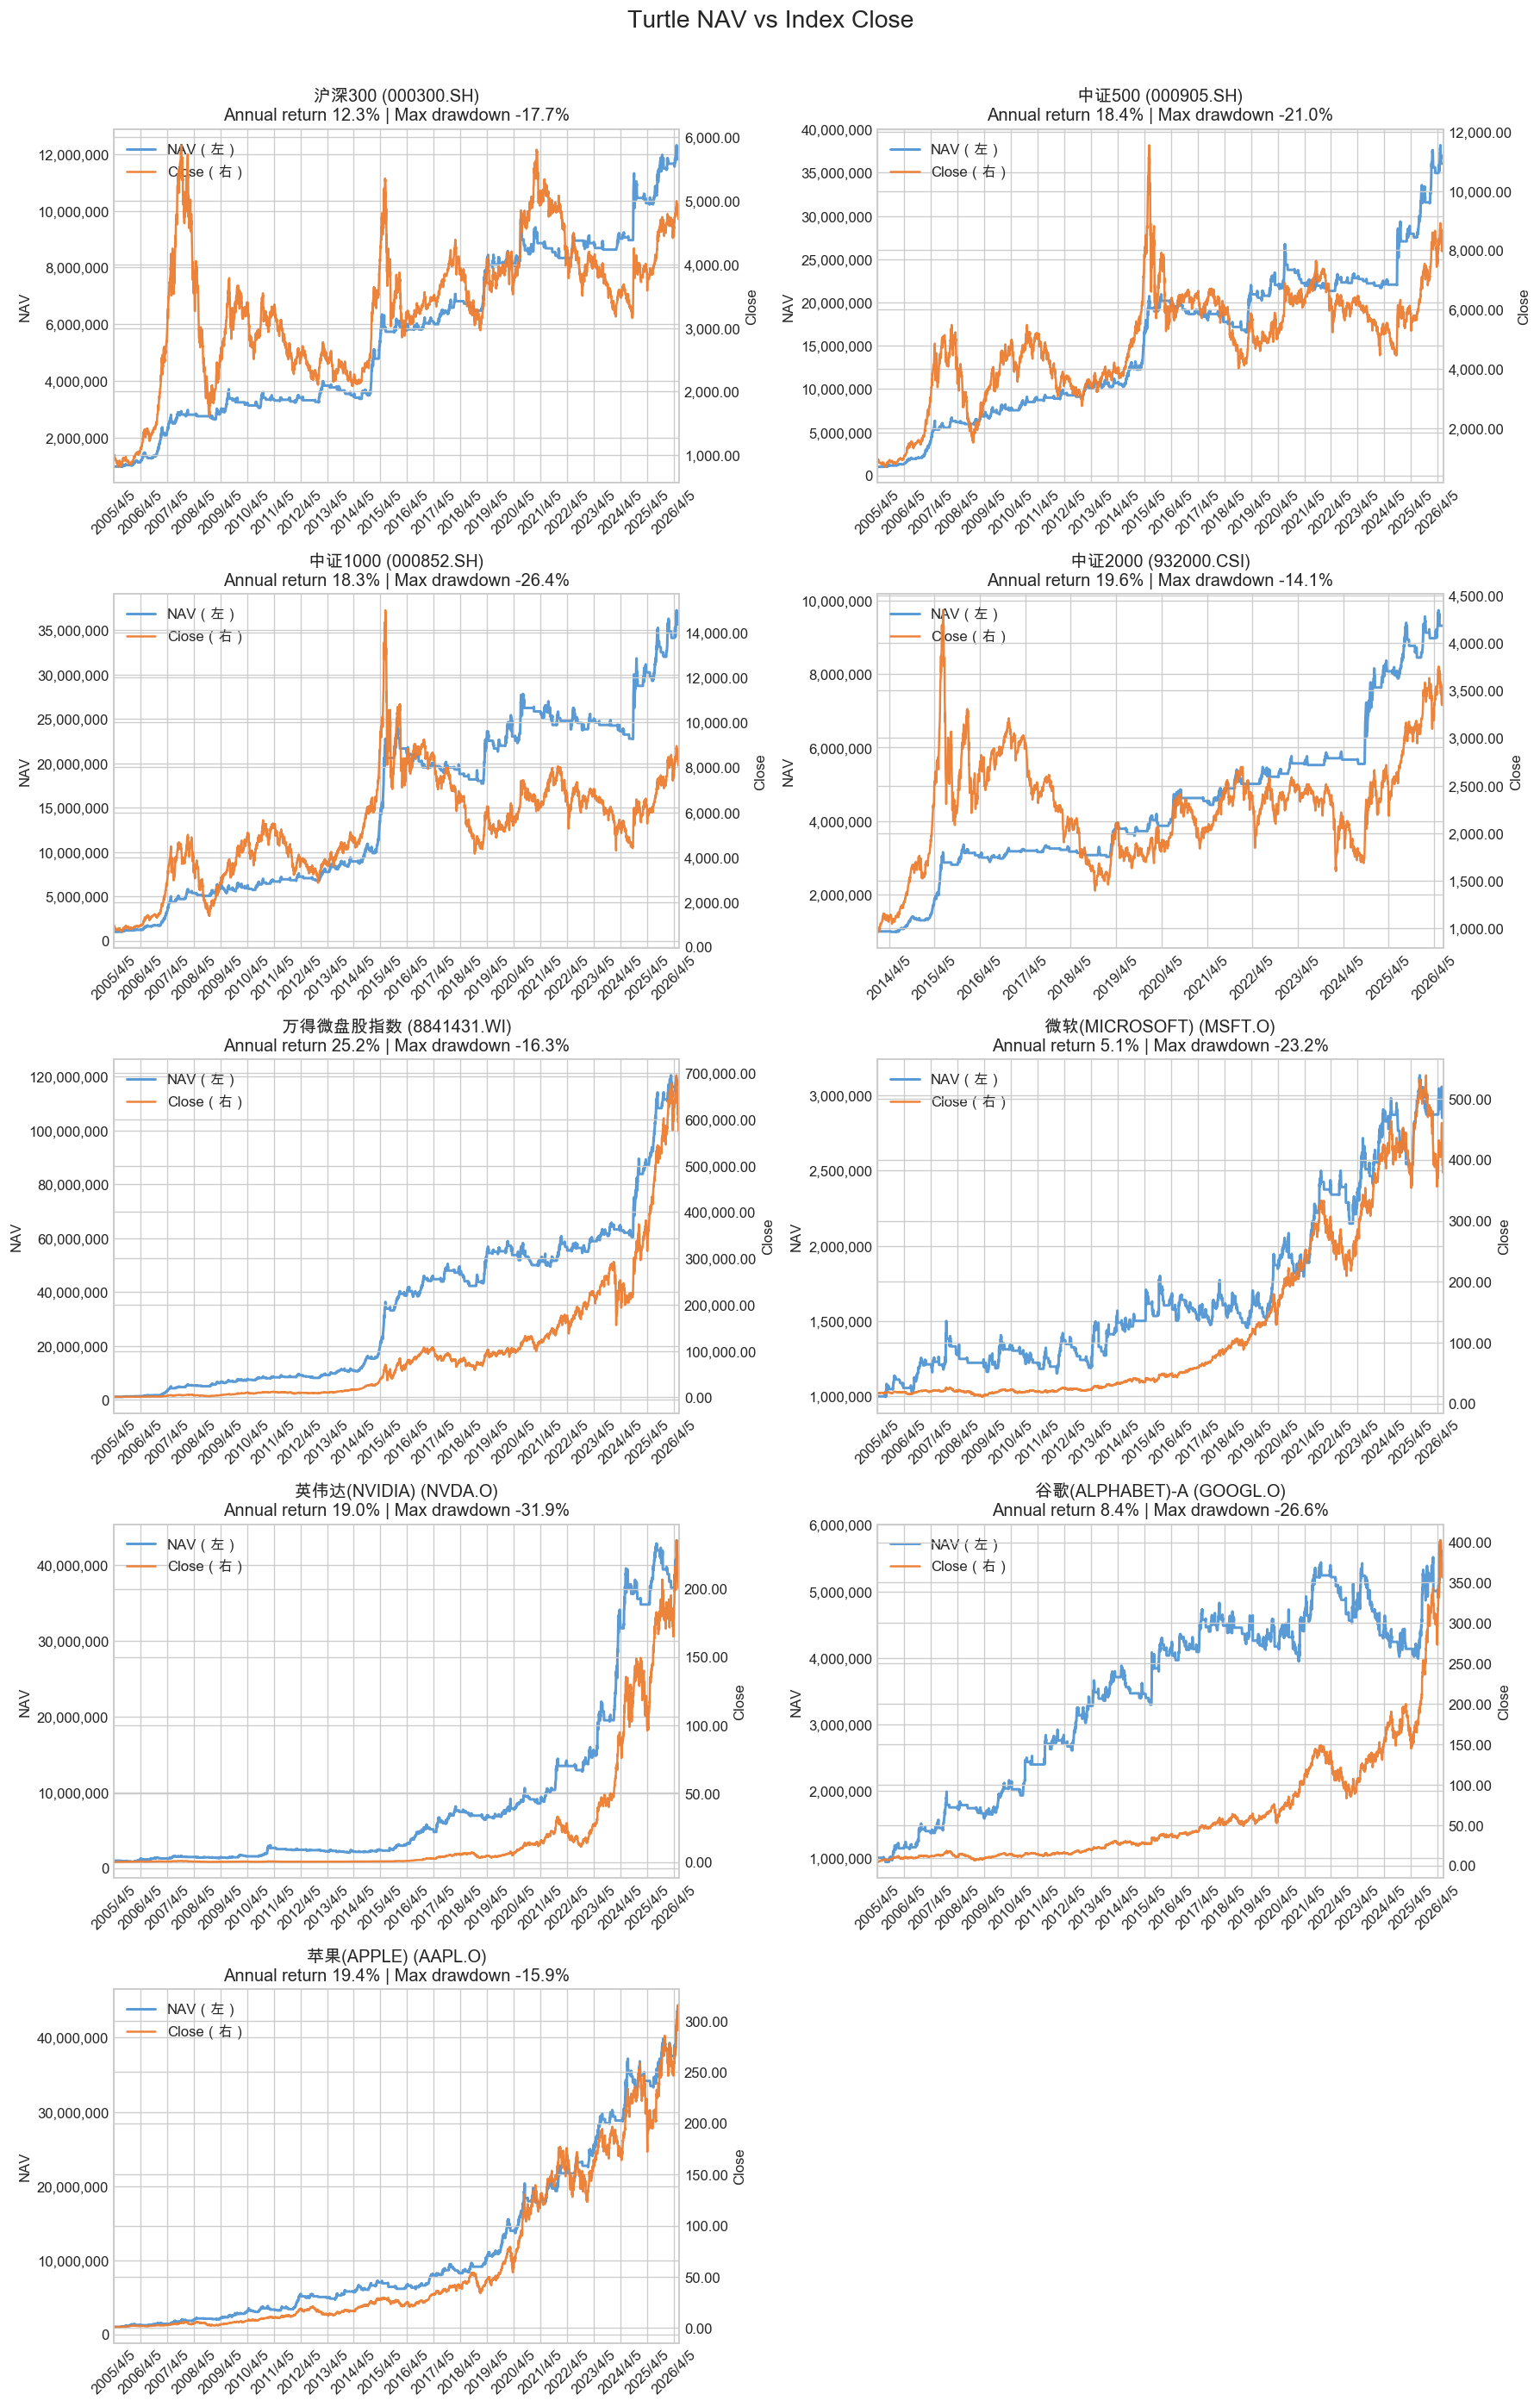

In [5]:
count = len(results)
ncols = 2
nrows = math.ceil(count / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.6 * nrows), squeeze=False)

for ax, (symbol, result) in zip(axes.flat, results.items()):
    frame = result["frame"]
    instrument = result["instrument"]
    summary = result["summary"]
    close_ax = ax.twinx()
    nav_line = ax.plot(frame.index, frame["NAV"], label="NAV（左）", color="#5b9bd5", linewidth=1.8)
    close_line = close_ax.plot(frame.index, frame["Close"], label="Close（右）", color="#ed7d31", linewidth=1.5, alpha=0.95)
    ax.set_title(
        f"{instrument.name} ({symbol})\n"
        f"Annual return {summary.annualized_return:.1%} | Max drawdown {summary.max_drawdown:.1%}"
    )
    ax.set_ylabel("NAV")
    close_ax.set_ylabel("Close")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    close_ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.2f}"))
    ax.xaxis.set_major_locator(mdates.YearLocator(base=1, month=4, day=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y/%-m/%-d"))
    ax.tick_params(axis="x", labelrotation=45)
    ax.set_xlim(frame.index.min(), frame.index.max())
    ax.legend(nav_line + close_line, [line.get_label() for line in nav_line + close_line], frameon=False, loc="upper left")

for ax in axes.flat[count:]:
    ax.set_visible(False)

fig.suptitle("Turtle NAV vs Index Close", fontsize=17, fontweight="bold", y=1.01)
fig.tight_layout()

if SAVE_CHARTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "index_nav_vs_close.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. 九个标的的海龟策略 NAV 对比

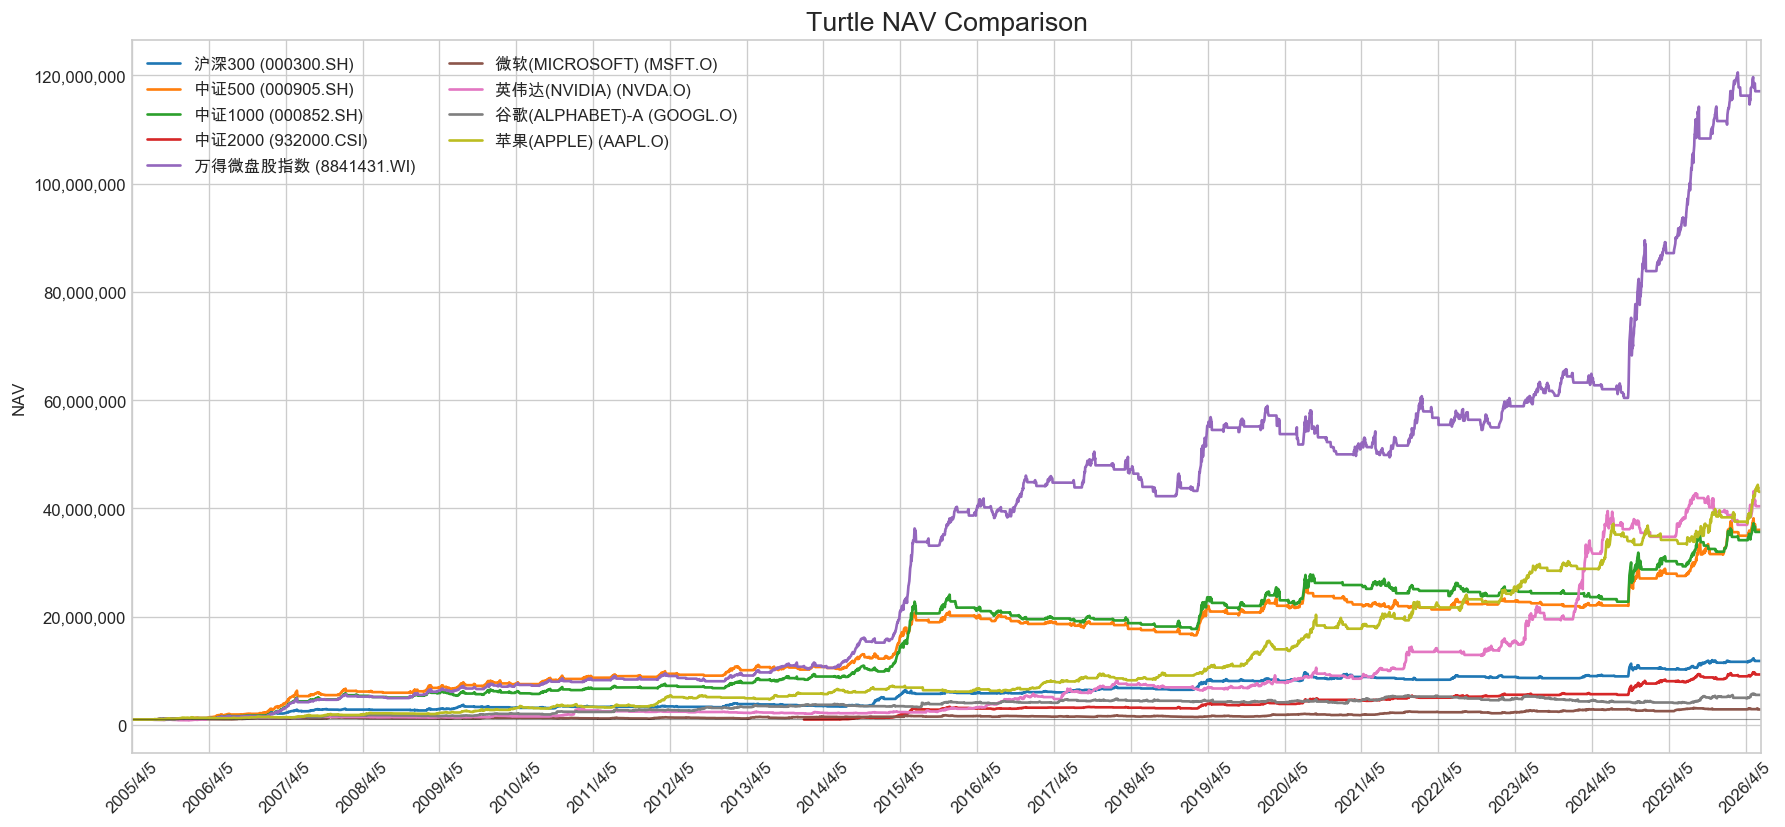

In [6]:
fig, ax = plt.subplots(figsize=(15, 7))
for symbol, result in results.items():
    frame = result["frame"]
    ax.plot(frame.index, frame["NAV"], linewidth=1.6, label=f'{result["instrument"].name} ({symbol})')

ax.axhline(PARAMETERS.initial_cash, color="black", linewidth=0.7, alpha=0.4)
ax.set_title("Turtle NAV Comparison", fontsize=16, fontweight="bold")
ax.set_ylabel("NAV")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.xaxis.set_major_locator(mdates.YearLocator(base=1, month=4, day=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y/%-m/%-d"))
ax.tick_params(axis="x", labelrotation=45)
ax.set_xlim(
    min(result["frame"].index.min() for result in results.values()),
    max(result["frame"].index.max() for result in results.values()),
)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()

if SAVE_CHARTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "turtle_nav_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. 回测指标汇总

In [7]:
summary_table = pd.DataFrame(summary_records).set_index("代码")
summary_table.style.format(
    {
        "期末净值": "{:,.0f}",
        "总收益率": "{:.1%}",
        "年化收益率": "{:.1%}",
        "最大回撤": "{:.1%}",
        "年化波动率": "{:.1%}",
        "夏普比率": "{:.2f}",
        "持仓时间": "{:.1%}",
    }
).background_gradient(subset=["年化收益率", "夏普比率"], cmap="Blues")

,名称,期末净值,总收益率,年化收益率,最大回撤,年化波动率,夏普比率,买入次数,持仓时间
代码,,,,,,,,,
000300.SH,沪深300,"11,815,917",1081.6%,12.3%,-17.7%,12.1%,1.06,119,36.2%
000905.SH,中证500,"36,039,527",3504.0%,18.4%,-21.0%,14.2%,1.31,120,37.9%
000852.SH,中证1000,"35,656,064",3465.6%,18.3%,-26.4%,14.8%,1.26,134,36.5%
932000.CSI,中证2000,"9,315,719",831.6%,19.6%,-14.1%,13.6%,1.43,67,36.3%
8841431.WI,万得微盘股指数,"117,068,769",11606.9%,25.2%,-16.3%,14.4%,1.69,132,46.0%
MSFT.O,微软(MICROSOFT),"2,850,662",185.1%,5.1%,-23.2%,12.8%,0.46,161,39.9%
NVDA.O,英伟达(NVIDIA),"40,396,865",3939.7%,19.0%,-31.9%,18.4%,1.07,145,41.3%
GOOGL.O,谷歌(ALPHABET)-A,"5,544,222",454.4%,8.4%,-26.6%,14.9%,0.64,161,41.4%
AAPL.O,苹果(APPLE),"43,060,433",4206.0%,19.4%,-15.9%,14.3%,1.36,135,44.6%
